# Diffusion Reweighting


The goal of this notebook is to run one of our "diffusion approaches" end-to-end. Here we reweight our eigenvectors when we reconstruct our symmmetric graph Laplacian with a weight equaling exp(-t·λ). The diffusion kernel `K_t = exp(-t·L)` is a *matrix function of the graph Laplacian* `L`. It therefore shares `L`'s eigenvectors exactly; only the eigenvalues transform, `λᵢ → exp(-t·λᵢ)`. So diffusion is implemented as a **reweighting of the Laplacian eigenvalues already computed by the normal spectral pipeline**, not as a new similarity matrix (something which I have tried before with mixed results and an over engineered spectral pipeline).


## Notebook Flow 

The notebook is divided into several sections and sub-sections but broadly I start off with a preamble (importing all the required packages), we then define all the reusable functions, present our data, run our baseline experiments (4 arms - fully-connected Gaussian, Gaussain diffused, k-nn and k-nn diffused, across several datasets with no noise perturbation)  and then run our noise perturb versions of the previously mentioned. 

## Imports

In [3]:
import sys
import os
import warnings

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import eigh
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score
from tqdm.notebook import tqdm

from clustering.alc import ALCAdapter
from data.generators import make_rings, make_two_moons, make_blobs

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# NOTE: scipy.linalg.expm is deliberately NOT imported — the old expm(-t*A_knn)
# construction is retired. Diffusion is done analytically via exp(-t*lambda).
print('Imports complete.')

Imports complete.


## Reusable Functions

### Utility Functions

In [4]:
def dist_mat(X):
    return cdist(X, X, 'euclidean')


def effective_rank(t, all_evals, threshold=1e-3):
    """Number of diffusion modes surviving at time t.

    K_t = exp(-t*L) shares L's eigenvectors; its eigenvalues are exp(-t*lambda_i).
    So the effective rank is a direct analytic function of the FIXED full spectrum
    `all_evals` and t — no matrix is re-formed, and nothing is re-decomposed per t.
    """
    return int(np.sum(np.exp(-t * all_evals) > threshold))


print('Utility functions defined.')

Utility functions defined.


### Affinity Construction

- `affinity_gaussian` — fully connected Gaussian kernel (feeds the `gaussian_baseline` arm)
- `affinity_knn` — k-NN masked Gaussian kernel (feeds both k-NN arms)

Diffusion is not a similarity matrix in this notebook — it is an eigenvalue reweighting applied downstream in
`reconstruct_and_cluster`.

In [5]:
def affinity_gaussian(dist_matrix, sigma):
    """Fully connected Gaussian kernel. Diagonal kept (self-similarity = 1)."""
    return np.exp(-dist_matrix**2 / (2.0 * sigma**2))


def affinity_knn(dist_matrix, k, sigma):
    """k-NN Gaussian affinity, symmetrised via OR rule."""
    n = dist_matrix.shape[0]
    if k >= n - 1:
        return affinity_gaussian(dist_matrix, sigma)
    nn_idx  = np.argsort(dist_matrix, axis=1)[:, 1:k + 1]
    nn_mask = np.zeros((n, n), dtype=bool)
    rows    = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True
    sym_mask = nn_mask | nn_mask.T
    np.fill_diagonal(sym_mask, True)
    W = np.exp(-dist_matrix**2 / (2.0 * sigma**2))
    return W * sym_mask


print('Affinity constructors defined (gaussian, knn — no diffusion kernel).')

Affinity constructors defined (gaussian, knn — no diffusion kernel).


### Laplacian Construction

In [6]:
def build_laplacian(A):
    """Symmetric normalised Laplacian: L = I - D^{-1/2} A D^{-1/2}."""
    d          = A.sum(axis=1)
    n          = len(d)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    D_inv_sqrt = np.diag(d_inv_sqrt)
    L          = np.eye(n) - D_inv_sqrt @ A @ D_inv_sqrt
    return L


print('build_laplacian defined.')

build_laplacian defined.


### Spectral Decomposition

In [7]:
def spectral_decompose(A, r):
    """Expensive step — run ONCE per (dataset, affinity_type, sigma, k).

    Pipeline: A -> L_sym (build_laplacian) -> eigh -> top-r eigenpair, NJW row-normalised.

    Returns
    -------
    U          : (n, r) top-r eigenvectors, NJW row-normalised
    lambdas    : (r,)   top-r eigenvalues of L_sym (ascending)
    all_evals  : (n,)   full ascending spectrum — for effective_rank / trajectories
    spectral_gap : float  all_evals[r] - all_evals[r-1] (does not depend on t)
    """
    L = build_laplacian(A)

    # eigh returns eigenvalues ascending — full spectrum kept for diagnostics
    all_evals, all_evecs = eigh(L)

    U       = all_evecs[:, :r]
    lambdas = all_evals[:r]

    # Ng-Jordan-Weiss row normalisation
    row_norms = np.sqrt(np.sum(U**2, axis=1, keepdims=True))
    U = U / np.maximum(row_norms, 1e-12)

    spectral_gap = float(all_evals[r] - all_evals[r - 1]) if len(all_evals) > r else np.nan

    return U, lambdas, all_evals, spectral_gap

### Reconstruction and Reweighting

In [8]:
def reconstruct_and_cluster(U, lambdas, all_evals, spectral_gap, y_true, t, seed=6):
    """Cheap step — run ONCE per t value, INCLUDING t = 0.

    weight = exp(-t * lambdas)     # single unified family; t=0 recovers U @ U.T exactly
    R_hat  = U @ diag(weight) @ U.T
    ... normalise to correlation form, clip to [-1, 1], run ALC, score ARI.

    Return schema matches the old run_single so downstream plotting stays compatible.
    """
    q = len(np.unique(y_true))

    # --- single unified diffusion family: exp(-t*lambda). t=0 -> all ones -> U @ U.T ---
    weight = np.exp(-t * lambdas)
    R_hat  = U @ np.diag(weight) @ U.T

    diag  = np.sqrt(np.diag(R_hat))
    diag  = np.where(diag == 0, 1, diag)
    R_hat = R_hat / np.outer(diag, diag)
    R_hat = np.clip(R_hat, -1, 1)

    np.random.seed(seed)
    alc    = ALCAdapter()
    labels = alc.fit_predict(R_hat, cn=None)

    ari              = adjusted_rand_score(y_true, labels)
    n_clusters_found = int(len(np.unique(labels)))

    return {
        't':                float(t),
        'ari':              ari,
        'n_clusters_found': n_clusters_found,
        'delta_k':          abs(n_clusters_found - q),
        'spectral_gap':     spectral_gap,
        'effective_rank':   effective_rank(t, all_evals),
        'labels':           labels,
        'eigenvectors':     U,
        'eigenvalues_L':    lambdas,
        'R_hat':            R_hat,
    }


### t-Hyperparameter Grid

In [9]:
def calibrate_t_grid(lambdas, weights=None):
    """Map a grid of target weights to diffusion times via t = -log(w) / lambda_r.

    The grid ALWAYS contains t = 0 exactly, so that every (dataset, sigma, k)
    configuration yields an undiffused baseline row. Two things would otherwise
    silently delete that row:

      * float dust — np.arange(0.05, 1.05, 0.05) ends at 1.0000000000000002,
        so -log(w) is a tiny NEGATIVE number rather than exactly 0.
      * the degenerate branch — when lambda_r is ~0 the old fallback emitted a
        flat array of 50.0 containing no zero at all, so the baseline arm came
        out empty (this is what produced the NaN knn_sparse rows).
    """
    if weights is None:
        weights = np.arange(0.05, 1.05, 0.05)  # 20 points: 0.05 to 1.00

    lambda_r = lambdas[-1]

    if lambda_r > 1e-6:
        t_values = -np.log(weights) / lambda_r
        t_values[np.isclose(t_values, 0.0)] = 0.0   # snap float dust to exact 0
    else:
        # Degenerate spectrum: exp(-t*lambda) ~ 1 for every t, so diffusion is a
        # no-op here. Still emit t = 0 so the undiffused baseline row exists.
        t_values = np.concatenate([[0.0], np.full(len(weights) - 1, 50.0)])

    grid = sorted(t_values)
    return grid, weights


## Datasets

Below I have all the datasets I have used for various iterations of testing and playing around with implementation of the diffusion kernel. The idea was that each of them test the inclusion of the diffusion step in some capacity. Note all these datasets will be included in final product. 

| # | Dataset | Explanation |
|---|---|---|
| 1 | `rings` | Three concentric circles — canonical non-convex case. |
| 2 | `two_moons` | Two interleaved crescents — standard non-convex benchmark. |
| 3 | `bottleneck` | Two Gaussian bars joined by a thin bridge — tests whether a weak path gets cut. |
| 4 | `multiscale` | One broad diffuse blob plus two tight small ones — clusters at different density scales. |
| 5 | `variable_moons` | Two moons with unequal sampling — tests fixed-k sensitivity to density. |
| 6 | `broken_rings` | Two rings with displaced points scattered in the gap. |
| 7 | `spirals` | Two interleaved Archimedean spirals — hardest geometric case. |
| 8 | `anisotropic` | Three elongated Gaussians at different rotations. |
| 9 | `noisy_moons` | 2-D moons embedded in 50-D with 48 pure-noise dimensions. |
| 10 | `synth` (Noh factor model) | Factor model matching ALC's own likelihood assumption; swept over D and g. |
| 11 | `digits` | sklearn handwritten digits, 64-D, 10 classes — the only real dataset. |


#### Code

In [10]:
# ---- Dataset generators — the original nine, in table order ----
import numpy as np
from sklearn.datasets import make_moons


# 1. rings — three concentric circles
def make_rings(n_points=1200, n_circles=3, noise_std=0.1, seed=0):
    rng = np.random.default_rng(seed)
    ring_labels = rng.choice(np.arange(1, n_circles + 1), n_points, replace=True)
    r = 2 * ring_labels + rng.normal(0, noise_std, n_points)
    theta = rng.uniform(0, 2 * np.pi, n_points)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    xy_coordinates = np.column_stack((x, y))
    return xy_coordinates, ring_labels


# 2. two_moons — two interleaved crescents
def make_two_moons(n_samples=1200, noise=0.05, seed=0):
    xy_coordinates, moon_labels = make_moons(n_samples=n_samples, noise=noise,
                                             random_state=seed)
    moon_labels = moon_labels + 1
    return xy_coordinates, moon_labels


# 3. bottleneck — two Gaussian bars joined by a thin bridge
def generate_bottleneck(n_per_cluster=300, n_bridge=15, seed=42):
    rng = np.random.RandomState(seed)
    X_0 = rng.multivariate_normal([0, 2], [[4.0, 0], [0, 0.2]], n_per_cluster)
    y_0 = np.zeros(n_per_cluster, dtype=int)
    X_1 = rng.multivariate_normal([0, -2], [[4.0, 0], [0, 0.2]], n_per_cluster)
    y_1 = np.ones(n_per_cluster, dtype=int)
    X_bridge = rng.uniform(-0.3, 0.3, (n_bridge, 1))
    y_bridge_vals = rng.uniform(-2, 2, (n_bridge, 1))
    X_b = np.hstack([X_bridge, y_bridge_vals])
    y_b = (X_b[:, 1] >= 0).astype(int)
    X = np.vstack([X_0, X_1, X_b]); y = np.concatenate([y_0, y_1, y_b])
    perm = rng.permutation(len(X)); return X[perm], y[perm]


# 4. multiscale — one broad blob plus two tight small ones
def generate_multiscale(n_large=400, n_small=100, seed=42):
    rng = np.random.RandomState(seed)
    X_large = rng.multivariate_normal([0, 0], [[3.0, 0], [0, 3.0]], n_large)
    y_large = np.zeros(n_large, dtype=int)
    X_s1 = rng.multivariate_normal([5, 1.5], [[0.15, 0], [0, 0.15]], n_small)
    y_s1 = np.ones(n_small, dtype=int)
    X_s2 = rng.multivariate_normal([5, -1.5], [[0.15, 0], [0, 0.15]], n_small)
    y_s2 = 2 * np.ones(n_small, dtype=int)
    X = np.vstack([X_large, X_s1, X_s2]); y = np.concatenate([y_large, y_s1, y_s2])
    perm = rng.permutation(len(X)); return X[perm], y[perm]


# 5. variable_moons — two moons with unequal sampling density
def generate_variable_density_moons(n_dense=500, n_sparse=50, noise=0.05, seed=42):
    rng = np.random.RandomState(seed)
    theta_dense = np.linspace(0, np.pi, n_dense)
    x_dense = np.cos(theta_dense) + rng.normal(0, noise, n_dense)
    y_dense = np.sin(theta_dense) + rng.normal(0, noise, n_dense)
    X_dense = np.column_stack([x_dense, y_dense])
    y_label_dense = np.zeros(n_dense, dtype=int)
    theta_sparse = np.linspace(0, np.pi, n_sparse)
    x_sparse = 1 - np.cos(theta_sparse) + rng.normal(0, noise, n_sparse)
    y_sparse = 0.5 - np.sin(theta_sparse) + rng.normal(0, noise, n_sparse)
    X_sparse = np.column_stack([x_sparse, y_sparse])
    y_label_sparse = np.ones(n_sparse, dtype=int)
    X = np.vstack([X_dense, X_sparse]); y = np.concatenate([y_label_dense, y_label_sparse])
    perm = rng.permutation(len(X)); return X[perm], y[perm]


# 6. broken_rings — two rings with displaced points in the gap
def generate_broken_rings(n_inner=300, n_outer=300, n_displaced=10, noise=0.05, seed=42):
    rng = np.random.RandomState(seed)
    theta_inner = rng.uniform(0, 2 * np.pi, n_inner)
    X_inner = np.column_stack([np.cos(theta_inner) + rng.normal(0, noise, n_inner),
                               np.sin(theta_inner) + rng.normal(0, noise, n_inner)])
    y_inner = np.zeros(n_inner, dtype=int)
    theta_outer = rng.uniform(0, 2 * np.pi, n_outer)
    X_outer = np.column_stack([3 * np.cos(theta_outer) + rng.normal(0, noise, n_outer),
                               3 * np.sin(theta_outer) + rng.normal(0, noise, n_outer)])
    y_outer = np.ones(n_outer, dtype=int)
    theta_disp = rng.uniform(0, 2 * np.pi, n_displaced)
    r_disp = rng.uniform(1.8, 2.2, n_displaced)
    X_disp = np.column_stack([r_disp * np.cos(theta_disp), r_disp * np.sin(theta_disp)])
    y_disp = np.zeros(n_displaced, dtype=int)
    X = np.vstack([X_inner, X_outer, X_disp]); y = np.concatenate([y_inner, y_outer, y_disp])
    perm = rng.permutation(len(X)); return X[perm], y[perm]


# 7. spirals — two interleaved Archimedean spirals
def generate_spirals(n_per_spiral=500, noise=0.3, seed=42):
    rng = np.random.RandomState(seed)
    t = np.linspace(0, 4 * np.pi, n_per_spiral); r0 = t
    X_0 = np.column_stack([r0 * np.cos(t) + rng.normal(0, noise, n_per_spiral),
                           r0 * np.sin(t) + rng.normal(0, noise, n_per_spiral)])
    y_0 = np.zeros(n_per_spiral, dtype=int)
    X_1 = np.column_stack([r0 * np.cos(t + np.pi) + rng.normal(0, noise, n_per_spiral),
                           r0 * np.sin(t + np.pi) + rng.normal(0, noise, n_per_spiral)])
    y_1 = np.ones(n_per_spiral, dtype=int)
    X = np.vstack([X_0, X_1]); y = np.concatenate([y_0, y_1])
    perm = rng.permutation(len(X)); return X[perm], y[perm]


# 8. anisotropic — three elongated Gaussians at different rotations
def generate_anisotropic(n_per_cluster=200, seed=42):
    rng = np.random.RandomState(seed)
    X_0 = rng.multivariate_normal([0, 4], [[5.0, 0], [0, 0.1]], n_per_cluster)
    y_0 = np.zeros(n_per_cluster, dtype=int)
    X_1 = rng.multivariate_normal([4, 0], [[0.1, 0], [0, 5.0]], n_per_cluster)
    y_1 = np.ones(n_per_cluster, dtype=int)
    angle = np.pi / 4
    R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    cov_2 = R @ np.array([[5.0, 0], [0, 0.1]]) @ R.T
    X_2 = rng.multivariate_normal([0, -4], cov_2, n_per_cluster)
    y_2 = 2 * np.ones(n_per_cluster, dtype=int)
    X = np.vstack([X_0, X_1, X_2]); y = np.concatenate([y_0, y_1, y_2])
    perm = rng.permutation(len(X)); return X[perm], y[perm]

def make_blobs_convex(N=1200, num_clusters=7, n_features=5000, seed=42):
    blobs, labels = make_blobs(
        n_samples=N, n_features=n_features, centers=num_clusters,
        shuffle=False, random_state=seed,
    )
    return blobs, labels

print('9 dataset generators defined.')


9 dataset generators defined.


#### Figures

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


def show(X, y, title, equal=True):
    """Scatter the first two dimensions, coloured by ground-truth label."""
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=10, alpha=0.75)
    ax.set_title(f"{title}\nn={len(X)}, D={X.shape[1]}, r={len(np.unique(y))}",
                 fontsize=10)
    if equal:
        ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Rings - Three concentric circles; canonical non-convex case

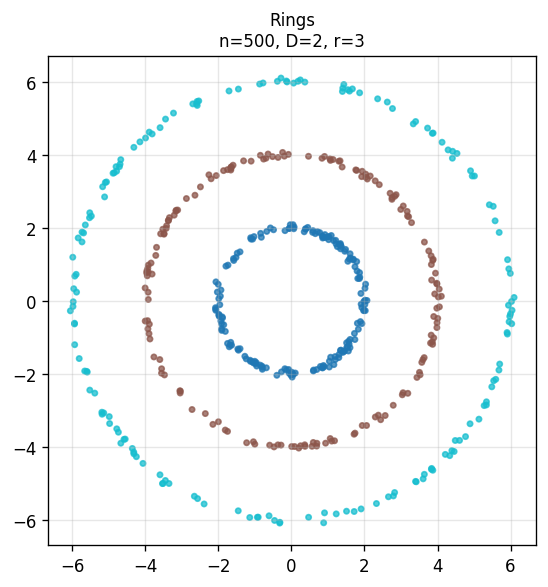

In [12]:
X_rings, y_rings = make_rings(n_points=500, n_circles=3, noise_std=0.05, seed=42)
show(X_rings, y_rings, 'Rings')


Two Moons - two interleaved crescents; standard non-convex benchmark

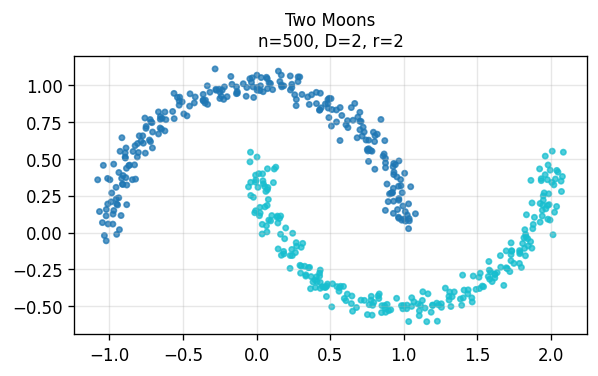

In [13]:
X_moons, y_moons = make_two_moons(n_samples=500, noise=0.05, seed=42)
show(X_moons, y_moons, 'Two Moons')


Bottleneck - two Gaussian bars joined by a thin bridge; tests whether a weak path gets cut

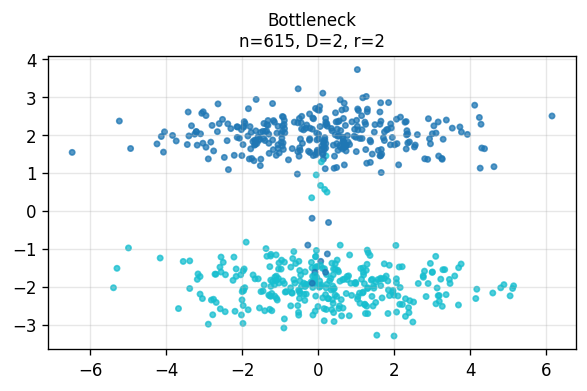

In [14]:
X_bottleneck, y_bottleneck = generate_bottleneck(n_per_cluster=300, n_bridge=15, seed=42)
show(X_bottleneck, y_bottleneck, 'Bottleneck')


Mutliscale - one broad diffuse blob plus two tight small ones; clusters at different density scales

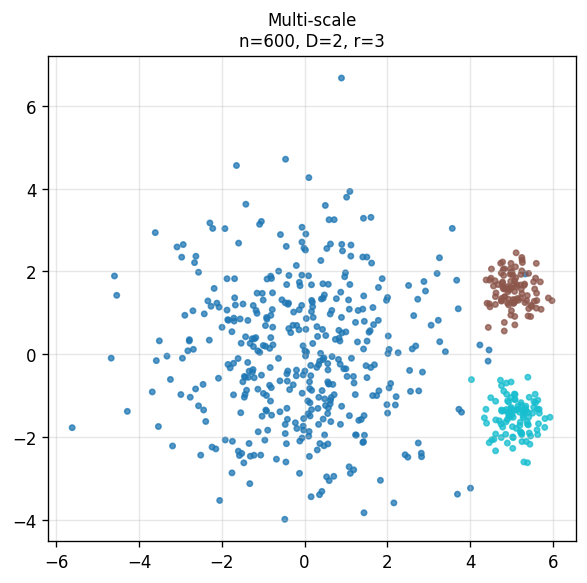

In [15]:
X_multiscale, y_multiscale = generate_multiscale(n_large=400, n_small=100, seed=42)
show(X_multiscale, y_multiscale, 'Multi-scale')


Variable Moons - two moons with unequal sampling (500 vs 50); tests fixed-k sensitivity to density

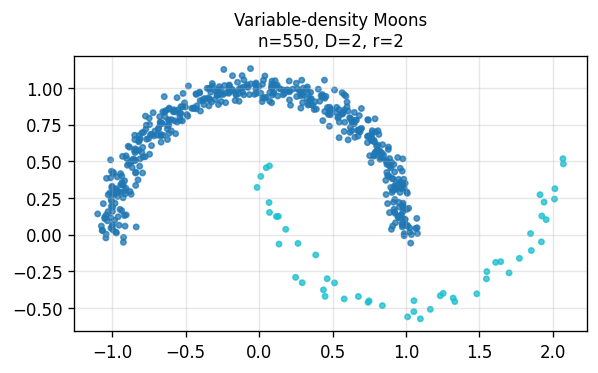

In [16]:
X_varmoons, y_varmoons = generate_variable_density_moons(
    n_dense=500, n_sparse=50, noise=0.05, seed=42)
show(X_varmoons, y_varmoons, 'Variable-density Moons')


Broken Rings - two rings with displaced points scattered in the gap

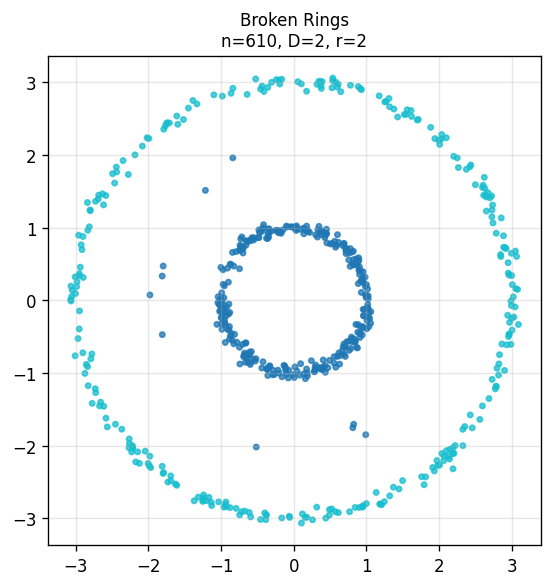

In [17]:
X_broken, y_broken = generate_broken_rings(
    n_inner=300, n_outer=300, n_displaced=10, noise=0.05, seed=42)
show(X_broken, y_broken, 'Broken Rings')


Spirals -  two interleaved Archimedean spirals; hardest geometric case

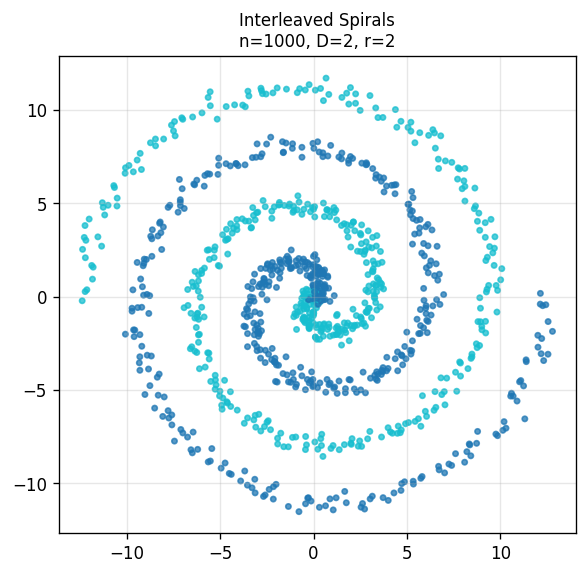

In [18]:
X_spirals, y_spirals = generate_spirals(n_per_spiral=500, noise=0.3, seed=42)
show(X_spirals, y_spirals, 'Interleaved Spirals')


Anisotropic - three elongated Gaussians at different rotations

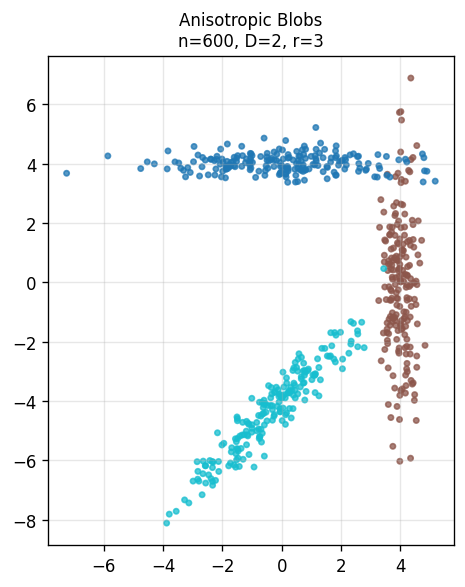

In [19]:
X_aniso, y_aniso = generate_anisotropic(n_per_cluster=200, seed=42)
show(X_aniso, y_aniso, 'Anisotropic Blobs')


Blobs - seven high dimenional clusters 

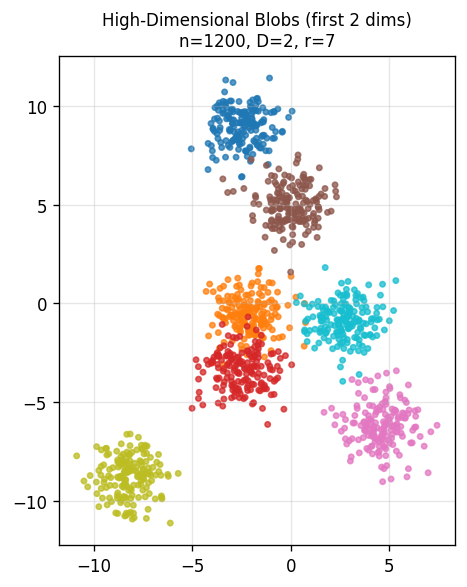

In [20]:
X_blobs, y_blobs = make_blobs_convex(N=1200, num_clusters=7, n_features=5000, seed=42)
show(X_blobs[:, :2], y_blobs, 'High-Dimensional Blobs (first 2 dims)')

## Baseline Experiments

For every dataset and every `(σ, k)`:

| Arm | Affinity `A` | `t` |
|---|---|---|
| `gaussian_baseline` | `affinity_gaussian(D, σ)` | `t = 0` only |
| `gaussian_diffusion` | `affinity_gaussian(D, σ)` | full calibrated grid, `t > 0` |
| `knn_sparse` | `affinity_knn(D, k, σ)` | `t = 0` only |
| `knn_diffusion` | `affinity_knn(D, k, σ)` | full calibrated grid, `t > 0` |

The four arms are a 2×2: **dense Gaussian vs. k-NN masked** affinity, crossed with
**`t = 0` vs. swept `t > 0`**. This isolates the two effects independently — hard
sparsification (k-NN masking) and soft sparsification (diffusion) — so the marginal
contribution of each can be read off separately rather than confounded.

**One decomposition per affinity per `(σ, k)`,** where `σ` is the Gaussian bandwidth in
`exp(−D²/2σ²)` — controlling how fast similarity decays with distance, so small `σ`
connects only very close points while large `σ` drives the graph toward all-ones — and `k`
is the number of nearest neighbours `affinity_knn` retains, zeroing everything outside each
point's k-NN set (symmetrised by OR rule). `gaussian_baseline` and `gaussian_diffusion`
share a single `spectral_decompose(A_gauss, r)`; `knn_sparse` and `knn_diffusion` share a
single `spectral_decompose(A_knn, r)`. Neither affinity is ever decomposed twice — `(U, λ)`
do not depend on `t`, so the expensive step runs once per `(σ, k)` while the cheap
eigenvalue reweighting runs once per `t`.


The `t = 0` point of each calibrated grid *is* the corresponding baseline row
(`gaussian_baseline` / `knn_sparse`); the `t > 0` points are the diffusion arms. Every arm
goes through `reconstruct_and_cluster`, and at `t = 0`, `weight = exp(0) = 1` recovers
`R̂ = U·Uᵀ` exactly — the original MSc dissertation method.


In [21]:
# ---- Per-dataset (sigma, k) grids -----------------------------------------
# Explicit raw sigma values, one list per dataset. sigma is the bandwidth in
# exp(-D^2 / 2*sigma^2), so it lives in the same units as the data's pairwise
# distances — the right scale differs per dataset and is set by hand here.
#
# The reference numbers below are each dataset's median pairwise distance under
# the OLD heuristic grid (multipliers 0.25 / 0.5 / 1.0 / 2.0 of the median), kept
# as a sanity anchor for choosing values:
#
#   rings           median ~5.36    old grid [ 1.34,  2.68,  5.36,  10.71]
#   two_moons       median ~1.16    old grid [ 0.29,  0.58,  1.16,   2.32]
#   bottleneck      median ~3.72    old grid [ 0.93,  1.86,  3.72,   7.43]
#   multiscale      median ~3.94    old grid [ 0.99,  1.97,  3.94,   7.89]
#   variable_moons  median ~0.99    old grid [ 0.25,  0.50,  0.99,   1.98]
#   broken_rings    median ~2.70    old grid [ 0.67,  1.35,  2.70,   5.39]
#   spirals         median ~8.84    old grid [ 2.21,  4.42,  8.84,  17.68]
#   anisotropic     median ~5.67    old grid [ 1.42,  2.83,  5.67,  11.33]
#   blobs           median ~585.6   old grid [146.39, 292.79, 585.58, 1171.16]

# Dissertation-reported ranges
sigma_blobs       = np.linspace(10, 500, 8)    # high-dimensional blobs
sigma_rings_moons = np.linspace(0.1, 2.0, 8)   # rings / two_moons family

DATASET_PARAMS = {
    'rings':          {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'two_moons':      {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'bottleneck':     {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'multiscale':     {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'variable_moons': {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'broken_rings':   {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'spirals':        {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'anisotropic':    {'sigma': sigma_rings_moons,  'k': [5, 10, 20], 'noise': [0.125, 0.25, 0.5]},
    'blobs':          {'sigma': sigma_blobs,  'k': [5, 10, 20], 'noise': [5, 25, 50]},
}

# Quick reference: recompute any dataset's median pairwise distance.
def median_dist(X):
    D = dist_mat(X)
    return float(np.median(D[np.triu_indices_from(D, k=1)]))


In [24]:
# ---- DATASETS registry -----------------------------------------------------
# Each entry is a dict: name, X, y, target rank r, and the per-dataset grids
# pulled from DATASET_PARAMS above (sigma, k, and the noise ladder).

_raw = [
    ('rings',          X_rings,      y_rings),
    ('two_moons',      X_moons,      y_moons),
    ('bottleneck',     X_bottleneck, y_bottleneck),
    ('multiscale',     X_multiscale, y_multiscale),
    ('variable_moons', X_varmoons,   y_varmoons),
    ('broken_rings',   X_broken,     y_broken),
    ('spirals',        X_spirals,    y_spirals),
    ('anisotropic',    X_aniso,      y_aniso),
    ('blobs',          X_blobs,      y_blobs),
]

_missing = [n for n, _, _ in _raw if n not in DATASET_PARAMS]
if _missing:
    raise KeyError(f"No DATASET_PARAMS entry for: {_missing}")

DATASETS = [
    {
        'name':         name,
        'X':            X,
        'y':            y,
        'r':            int(len(np.unique(y))),
        'sigma_values': list(DATASET_PARAMS[name]['sigma']),
        'k_values':     list(DATASET_PARAMS[name]['k']),
        # noise ladder: per-dataset if given, else the global fallback
        'noise_levels': list(DATASET_PARAMS[name]["noise"]),
    }
    for name, X, y in _raw
]

assert all(isinstance(d, dict) for d in DATASETS), "registry is not dicts"

print(f"{len(DATASETS)} datasets registered.\n")
for ds in DATASETS:
    sig = ', '.join(f"{s:g}" for s in ds['sigma_values'])
    ks  = ', '.join(str(k) for k in ds['k_values'])
    nz  = ', '.join(f"{v:g}" for v in ds['noise_levels'])
    med = median_dist(ds['X'])
    n_cfg = len(ds['sigma_values']) * (1 + len(ds['k_values']))
    print(f"  {ds['name']:<16} n={len(ds['X']):>4}  Dim={ds['X'].shape[1]:>4}  "
          f"r={ds['r']}  median_d={med:>8.2f}  decomps/draw={n_cfg:>3}")
    print(f"  {'':<16} sigma=[{sig}]")
    print(f"  {'':<16} k=[{ks}]   noise xi=[{nz}]")

# Cost accounting: level 0.0 is deterministic, so it gets a single draw.
#def _n_draws(ds):
#    return sum(1 if lvl == 0.0 else N_REPEATS for lvl in ds['noise_levels'])

#base_total  = sum(len(d['sigma_values']) * (1 + len(d['k_values'])) for d in DATASETS)
#noise_total = sum(len(d['sigma_values']) * (1 + len(d['k_values'])) * _n_draws(d)
#                  for d in DATASETS)
#print(f"\nDecompositions — baseline run: {base_total}   noise run: {noise_total}")


9 datasets registered.

  rings            n= 500  Dim=   2  r=3  median_d=    5.36  decomps/draw= 32
                   sigma=[0.1, 0.371429, 0.642857, 0.914286, 1.18571, 1.45714, 1.72857, 2]
                   k=[5, 10, 20]   noise xi=[0.125, 0.25, 0.5]
  two_moons        n= 500  Dim=   2  r=2  median_d=    1.16  decomps/draw= 32
                   sigma=[0.1, 0.371429, 0.642857, 0.914286, 1.18571, 1.45714, 1.72857, 2]
                   k=[5, 10, 20]   noise xi=[0.125, 0.25, 0.5]
  bottleneck       n= 615  Dim=   2  r=2  median_d=    3.72  decomps/draw= 32
                   sigma=[0.1, 0.371429, 0.642857, 0.914286, 1.18571, 1.45714, 1.72857, 2]
                   k=[5, 10, 20]   noise xi=[0.125, 0.25, 0.5]
  multiscale       n= 600  Dim=   2  r=3  median_d=    3.94  decomps/draw= 32
                   sigma=[0.1, 0.371429, 0.642857, 0.914286, 1.18571, 1.45714, 1.72857, 2]
                   k=[5, 10, 20]   noise xi=[0.125, 0.25, 0.5]
  variable_moons   n= 550  Dim=   2  r=2  median

In [ ]:
import time

results = []
t_start = time.time()

for ds in tqdm(DATASETS, desc='Datasets'):
    name, X, y, r = ds['name'], ds['X'], ds['y'], ds['r']
    D    = dist_mat(X)
    t_ds = time.time()
    print(f"\n[{name}] n={len(X)}, dims={X.shape[1]}, r={r}")

    # ===== gaussian_baseline (t=0) + gaussian_diffusion (t>0) =====
    # ONE decomposition per sigma, shared by both Gaussian arms.
    for sigma in ds['sigma_values']:
        A_g = affinity_gaussian(D, sigma)
        Ug, lam_g, allg, gap_g = spectral_decompose(A_g, r)

        t_grid, _ = calibrate_t_grid(lam_g)
        print(f"  gauss (sigma={sigma:>6.3f})          lambda_r={lam_g[-1]:.4f}  "
              f"t_max={max(t_grid):.4f}")

        for t in t_grid:
            out = reconstruct_and_cluster(Ug, lam_g, allg, gap_g, y, t=t)
            if np.isclose(t, 0.0):
                arm, eff, t_val = 'gaussian_baseline', np.nan, np.nan
            else:
                arm, eff, t_val = 'gaussian_diffusion', out['effective_rank'], t
            results.append({
                'dataset': name, 'arm': arm, 'sigma': sigma, 'k': np.nan,
                't': t_val, 'ari': out['ari'],
                'n_clusters_found': out['n_clusters_found'], 'delta_k': out['delta_k'],
                'spectral_gap': out['spectral_gap'], 'effective_rank': eff,
            })

    # ===== knn_sparse (t=0) + knn_diffusion (t>0) =====
    # ONE decomposition per (sigma, k), shared by both k-NN arms.
    for sigma in ds['sigma_values']:
        for k in ds['k_values']:
            A_knn = affinity_knn(D, k, sigma)
            Uk, lam_k, allk, gap_k = spectral_decompose(A_knn, r)

            t_grid, _ = calibrate_t_grid(lam_k)
            print(f"  knn   (sigma={sigma:>6.3f}, k={k:>2d})  lambda_r={lam_k[-1]:.4f}  "
                  f"t_max={max(t_grid):.4f}")

            for t in t_grid:
                out = reconstruct_and_cluster(Uk, lam_k, allk, gap_k, y, t=t)
                if np.isclose(t, 0.0):
                    arm, eff, t_val = 'knn_sparse', np.nan, np.nan
                else:
                    arm, eff, t_val = 'knn_diffusion', out['effective_rank'], t
                results.append({
                    'dataset': name, 'arm': arm, 'sigma': sigma, 'k': k,
                    't': t_val, 'ari': out['ari'],
                    'n_clusters_found': out['n_clusters_found'], 'delta_k': out['delta_k'],
                    'spectral_gap': out['spectral_gap'], 'effective_rank': eff,
                })

    print(f"  [{name}] done in {time.time() - t_ds:.0f}s")

df = pd.DataFrame(results)
print(f"\nGrid complete: {len(df)} rows in {(time.time() - t_start) / 60:.1f} min")
print(df.groupby('arm').size().to_string())
df.head()


In [ ]:
df.to_csv('diffusion_reweighting_baseline_results.csv', index=False)
print(f"Saved {len(df)} rows -> diffusion_reweighting_baseline_results.csv")

## Baseline Results

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = pd.read_csv('diffusion_reweighting_baseline_results.csv')

ARMS   = ['gaussian_baseline', 'gaussian_diffusion', 'knn_sparse', 'knn_diffusion']
COLORS = dict(zip(ARMS, ['#4C78A8', '#9ECAE9', '#E45756', '#FFBF79']))
DATASET_ORDER = [d for d in df['dataset'].unique()]


# Best ARI achieved by each arm on each dataset (oracle over sigma, k, t).
best = (df.groupby(['dataset', 'arm'])['ari'].max()
          .unstack()
          .reindex(index=DATASET_ORDER, columns=ARMS))

print("Best ARI per dataset x arm (oracle over hyperparameters)\n")
print(best.round(3).to_string())
print("\nMarginal gain from diffusion (best diffused - best undiffused):\n")
gain = pd.DataFrame({
    'gaussian': best['gaussian_diffusion'] - best['gaussian_baseline'],
    'knn':      best['knn_diffusion']      - best['knn_sparse'],
})
print(gain.round(3).to_string())


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))

x = np.arange(len(DATASET_ORDER))
w = 0.2
for i, arm in enumerate(ARMS):
    ax.bar(x + (i - 1.5) * w, best[arm].values, w, label=arm, color=COLORS[arm])

ax.set_xticks(x)
ax.set_xticklabels(DATASET_ORDER, rotation=30, ha='right')
ax.set_ylabel('Best ARI (oracle over $\\sigma$, k, t)')
ax.set_title('Baseline: best ARI by arm and dataset')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend(ncol=4, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.28))
plt.tight_layout()
plt.show()


In [ ]:
# 3x3 grid: 9 datasets. A 2x4 grid would silently drop the 9th via the zip().
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharey=True)

for ax, ds in zip(axes.ravel(), DATASET_ORDER):
    sub = df[df['dataset'] == ds]

    # --- k-NN diffusion trajectory at the best (sigma, k) ---
    kd = sub[sub['arm'] == 'knn_diffusion']
    if len(kd):
        bs, bk = kd.loc[kd['ari'].idxmax(), ['sigma', 'k']]
        tr = kd[(kd['sigma'] == bs) & (kd['k'] == bk)].sort_values('t')
        ax.plot(tr['t'], tr['ari'], '-o', ms=3, color=COLORS['knn_diffusion'],
                label=f'knn_diffusion (k={int(bk)})')
        b0 = sub[(sub['arm'] == 'knn_sparse') & (sub['sigma'] == bs) & (sub['k'] == bk)]['ari']
        if len(b0):
            ax.axhline(b0.iloc[0], ls='--', lw=1, color=COLORS['knn_sparse'],
                       label='knn_sparse (t=0)')

    # --- Gaussian diffusion trajectory at the best sigma ---
    gd = sub[sub['arm'] == 'gaussian_diffusion']
    if len(gd):
        gs = gd.loc[gd['ari'].idxmax(), 'sigma']
        tr = gd[gd['sigma'] == gs].sort_values('t')
        ax.plot(tr['t'], tr['ari'], '-s', ms=3, color=COLORS['gaussian_diffusion'],
                label='gaussian_diffusion')
        b0 = sub[(sub['arm'] == 'gaussian_baseline') & (sub['sigma'] == gs)]['ari']
        if len(b0):
            ax.axhline(b0.iloc[0], ls='--', lw=1, color=COLORS['gaussian_baseline'],
                       label='gaussian_baseline (t=0)')

    ax.set_title(ds, fontsize=9)
    ax.set_xscale('symlog', linthresh=1e-2)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=6)

# blank any unused panels (none at 9 datasets, but safe if the registry changes)
for ax in axes.ravel()[len(DATASET_ORDER):]:
    ax.axis('off')

for ax in axes[-1]:
    ax.set_xlabel('diffusion time t')
for ax in axes[:, 0]:
    ax.set_ylabel('ARI')

fig.suptitle('ARI vs diffusion time at best $(\\sigma, k)$ — dashed = undiffused baseline', y=1.00)
plt.tight_layout()
plt.show()


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- left: does any arm recover the right number of clusters? ---
hit = (df.assign(exact=(df['delta_k'] == 0))
         .groupby(['dataset', 'arm'])['exact'].mean()
         .unstack().reindex(index=DATASET_ORDER, columns=ARMS))
x = np.arange(len(DATASET_ORDER))
for i, arm in enumerate(ARMS):
    ax1.bar(x + (i - 1.5) * 0.2, hit[arm].values, 0.2, label=arm, color=COLORS[arm])
ax1.set_xticks(x); ax1.set_xticklabels(DATASET_ORDER, rotation=30, ha='right')
ax1.set_ylabel('fraction of configs with $\\Delta k = 0$')
ax1.set_title('Cluster-count recovery rate')
ax1.grid(axis='y', alpha=0.3); ax1.legend(fontsize=7)

# --- right: marginal gain from turning diffusion on ---
g = gain.reindex(DATASET_ORDER)
ax2.barh(x - 0.2, g['gaussian'].values, 0.4, label='gaussian', color=COLORS['gaussian_diffusion'])
ax2.barh(x + 0.2, g['knn'].values,      0.4, label='k-NN',     color=COLORS['knn_diffusion'])
ax2.axvline(0, color='k', lw=1)
ax2.set_yticks(x); ax2.set_yticklabels(DATASET_ORDER)
ax2.set_xlabel('$\\Delta$ ARI (best diffused $-$ best undiffused)')
ax2.set_title('Marginal contribution of diffusion')
ax2.grid(axis='x', alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Noise Perturbed Experiments

In [25]:
# ---- Noise perturbation ----------------------------------------------------
# Entrywise additive Gaussian noise:
#
#     X_tilde = X + eps,     eps_ij ~ N(0, xi^2)
#
# for a data matrix X in R^{n x d} and noise level xi. Every entry is perturbed
# independently, so xi is a standard deviation in the DATA'S OWN UNITS — not a
# fraction of any distance or spread.
#
# Because xi is in raw units, its meaningful range differs per dataset, which is
# why the ladder lives in DATASET_PARAMS['noise'] rather than in one global list:
# the 2-D sets use [0.125, 0.25, 0.5] while blobs uses [5, 25, 50].


def perturb(X, noise_level, seed=0):
    """Entrywise Gaussian perturbation: X_tilde = X + eps, eps_ij ~ N(0, xi^2).

    Parameters
    ----------
    X           : (n, d) clean data matrix
    noise_level : float, the noise sd xi, in the same units as X.
                  0.0 returns X unchanged.
    seed        : int, RNG seed — vary this for repeat draws at the same level.

    Returns
    -------
    (n, d) perturbed copy. X is never modified in place.
    """
    if noise_level == 0.0:
        return X.copy()
    rng = np.random.default_rng(seed)
    return X + rng.normal(0.0, noise_level, X.shape)


# Fallback ladder, used only if a dataset omits 'noise' in DATASET_PARAMS.
# All nine currently define their own, so this is a safety net.
NOISE_LEVELS  = [0.0, 0.125, 0.25, 0.5]
N_REPEATS     = 1                         # independent draws per level
PERTURB_SEEDS = [100, 200, 300][:N_REPEATS]

print("perturb: X_tilde = X + eps,  eps_ij ~ N(0, xi^2)   [xi in raw data units]")
print(f"Fallback ladder:   {NOISE_LEVELS}")
print(f"Repeats per level: {N_REPEATS} (seeds {PERTURB_SEEDS})")


perturb: X_tilde = X + eps,  eps_ij ~ N(0, xi^2)   [xi in raw data units]
Fallback ladder:   [0.0, 0.125, 0.25, 0.5]
Repeats per level: 1 (seeds [100])


In [ ]:
# Noise ladder: one row per dataset, columns = that dataset's own xi values.
# Each row is prefixed with the CLEAN data so the perturbation is visible as a
# change, even though xi = 0 is not part of every ladder. Ladders may differ in
# length between datasets, so the grid is sized to the longest and any leftover
# panels are blanked.
#
# Note: only the first two dimensions are scattered. For blobs (d=5000) that is
# a 2-D slice of a high-dimensional cloud, so neither the structure nor the
# apparent noise magnitude is representative.

_rows  = [(ds, [0.0] + list(ds['noise_levels'])) for ds in DATASETS]
_ncols = max(len(lv) for _, lv in _rows)

fig, axes = plt.subplots(len(_rows), _ncols,
                         figsize=(2.4 * _ncols, 2.4 * len(_rows)),
                         squeeze=False)

for i, (ds, levels) in enumerate(_rows):
    for j in range(_ncols):
        ax = axes[i][j]
        if j >= len(levels):
            ax.axis('off')
            continue

        lvl = levels[j]
        Xp  = perturb(ds['X'], lvl, seed=PERTURB_SEEDS[0])
        ax.scatter(Xp[:, 0], Xp[:, 1], c=ds['y'], cmap='tab10', s=3, alpha=0.6)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title('clean' if lvl == 0.0 else f'$\\xi$ = {lvl:g}', fontsize=8)
        if j == 0:
            ax.set_ylabel(ds['name'], fontsize=8)

fig.suptitle('Noise ladder — $\\tilde{X} = X + \\epsilon$, '
             '$\\epsilon_{ij} \\sim N(0, \\xi^2)$  [$\\xi$ in raw data units]',
             y=1.001)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# NOISE DRIVER — fixed (sigma, k) grids and per-dataset noise ladders
# ============================================================================
# sigma and k come from the registry, i.e. the SAME grids used for the clean
# baseline, so every noise row is directly comparable to its baseline row. This
# holds sigma fixed as noise rises: robustness of a DEPLOYED configuration,
# not of the method-plus-retuning.
#
# Noise levels come from ds['noise_levels'], which the registry populates from
# DATASET_PARAMS[name]['noise']. The guard below refuses to run if the live
# registry disagrees with DATASET_PARAMS — that mismatch is what silently ran
# blobs on the 2-D ladder [0.125, 0.25, 0.5] instead of its own [5, 25, 50].

import time

# --- guard: refuse to run against a stale registry ---------------------------
for _ds in DATASETS:
    _want = list(DATASET_PARAMS[_ds['name']]['noise'])
    _got  = list(_ds['noise_levels'])
    if _want != _got:
        raise RuntimeError(
            f"Stale registry for '{_ds['name']}': noise_levels={_got} "
            f"but DATASET_PARAMS says {_want}.\n"
            f"Re-run the DATASET_PARAMS cell, then the registry cell, then this."
        )

print("Registry matches DATASET_PARAMS. Ladders confirmed:")
for _ds in DATASETS:
    print(f"  {_ds['name']:<16} xi = {_ds['noise_levels']}")
print()


def _seeds_for(lvl):
    """Level 0.0 is deterministic — one draw; repeats would be identical rows."""
    return PERTURB_SEEDS if lvl > 0.0 else PERTURB_SEEDS[:1]


noise_results = []
t_start = time.time()

total = sum(len(_seeds_for(l)) for ds in DATASETS for l in ds['noise_levels'])
pbar  = tqdm(total=total, desc='dataset x noise x repeat')

for ds in DATASETS:
    name, X_clean, y, r = ds['name'], ds['X'], ds['y'], ds['r']
    sigmas, ks, levels = ds['sigma_values'], ds['k_values'], ds['noise_levels']
    t_ds = time.time()

    print(f"\n[{name}] n={len(X_clean)}, dims={X_clean.shape[1]}, r={r}  |  "
          f"{len(sigmas)} sigma x {len(ks)} k = {len(sigmas) * (1 + len(ks))} decomps/draw  "
          f"|  xi={levels}")

    for lvl in levels:
        for rep, pseed in enumerate(_seeds_for(lvl)):
            X = perturb(X_clean, lvl, seed=pseed)
            D = dist_mat(X)

            meta = {'dataset': name, 'noise_level': lvl,
                    'repeat': rep, 'perturb_seed': pseed}

            # ===== gaussian_baseline (t=0) + gaussian_diffusion (t>0) =====
            # ONE decomposition per sigma, shared by both Gaussian arms.
            for sigma in sigmas:
                A_g = affinity_gaussian(D, sigma)
                Ug, lam_g, allg, gap_g = spectral_decompose(A_g, r)
                t_grid, _ = calibrate_t_grid(lam_g)

                for t in t_grid:
                    out = reconstruct_and_cluster(Ug, lam_g, allg, gap_g, y, t=t)
                    if np.isclose(t, 0.0):
                        arm, eff, t_val = 'gaussian_baseline', np.nan, np.nan
                    else:
                        arm, eff, t_val = 'gaussian_diffusion', out['effective_rank'], t
                    noise_results.append({
                        **meta, 'arm': arm, 'sigma': sigma, 'k': np.nan, 't': t_val,
                        'ari': out['ari'], 'n_clusters_found': out['n_clusters_found'],
                        'delta_k': out['delta_k'], 'spectral_gap': out['spectral_gap'],
                        'effective_rank': eff,
                    })

            # ===== knn_sparse (t=0) + knn_diffusion (t>0) =====
            # ONE decomposition per (sigma, k), shared by both k-NN arms.
            for sigma in sigmas:
                for k in ks:
                    A_knn = affinity_knn(D, k, sigma)
                    Uk, lam_k, allk, gap_k = spectral_decompose(A_knn, r)
                    t_grid, _ = calibrate_t_grid(lam_k)

                    for t in t_grid:
                        out = reconstruct_and_cluster(Uk, lam_k, allk, gap_k, y, t=t)
                        if np.isclose(t, 0.0):
                            arm, eff, t_val = 'knn_sparse', np.nan, np.nan
                        else:
                            arm, eff, t_val = 'knn_diffusion', out['effective_rank'], t
                        noise_results.append({
                            **meta, 'arm': arm, 'sigma': sigma, 'k': k, 't': t_val,
                            'ari': out['ari'], 'n_clusters_found': out['n_clusters_found'],
                            'delta_k': out['delta_k'], 'spectral_gap': out['spectral_gap'],
                            'effective_rank': eff,
                        })

            pbar.update(1)

    print(f"  [{name}] done in {time.time() - t_ds:.0f}s")

pbar.close()

df_noise = pd.DataFrame(noise_results)
print(f"\nNoise grid complete: {len(df_noise)} rows in {(time.time() - t_start) / 60:.1f} min")
print(df_noise.groupby('arm').size().to_string())

# sanity: every dataset must have run its OWN ladder
print("\nLadder actually run, per dataset:")
print(df_noise.groupby('dataset')['noise_level']
      .apply(lambda s: sorted(s.unique())).to_string())
print("\nDraws per (dataset, level):")
print(df_noise.groupby(['dataset', 'noise_level'])['perturb_seed']
      .nunique().unstack().to_string())

df_noise.to_csv('diffusion_reweighting_noise_results.csv', index=False)
print("\nSaved -> diffusion_reweighting_noise_results.csv")
df_noise.head()


## Noise Perturbed Results

In [26]:
# ---- Noise run: blobs only -------------------------------------------------
# Same driver logic, restricted to one dataset and written to its own CSV so
# the full-run results file is untouched.

import time

TARGET = 'blobs'

_sel = [d for d in DATASETS if d['name'] == TARGET]
if not _sel:
    raise KeyError(f"'{TARGET}' not in DATASETS: {[d['name'] for d in DATASETS]}")
ds = _sel[0]

# guard: registry must agree with DATASET_PARAMS for this dataset
_want = list(DATASET_PARAMS[TARGET]['noise'])
_got  = list(ds['noise_levels'])
if _want != _got:
    raise RuntimeError(
        f"Stale registry for '{TARGET}': noise_levels={_got} but "
        f"DATASET_PARAMS says {_want}. Re-run DATASET_PARAMS, then the registry."
    )

name, X_clean, y, r = ds['name'], ds['X'], ds['y'], ds['r']
sigmas, ks, levels  = ds['sigma_values'], ds['k_values'], ds['noise_levels']

print(f"[{name}] n={len(X_clean)}, dims={X_clean.shape[1]}, r={r}")
print(f"  sigma = {[f'{s:g}' for s in sigmas]}")
print(f"  k     = {ks}")
print(f"  xi    = {levels}   (median pairwise distance = {median_dist(X_clean):.1f})")
print(f"  {len(sigmas) * (1 + len(ks))} decomps/draw\n")

blob_results = []
t_start = time.time()

total = sum(1 if l == 0.0 else N_REPEATS for l in levels)
pbar  = tqdm(total=total, desc=f'{TARGET}: noise x repeat')

for lvl in levels:
    seeds = PERTURB_SEEDS if lvl > 0.0 else PERTURB_SEEDS[:1]

    for rep, pseed in enumerate(seeds):
        X = perturb(X_clean, lvl, seed=pseed)
        D = dist_mat(X)

        meta = {'dataset': name, 'noise_level': lvl,
                'repeat': rep, 'perturb_seed': pseed}

        # ===== gaussian_baseline (t=0) + gaussian_diffusion (t>0) =====
        for sigma in sigmas:
            A_g = affinity_gaussian(D, sigma)
            Ug, lam_g, allg, gap_g = spectral_decompose(A_g, r)
            t_grid, _ = calibrate_t_grid(lam_g)

            for t in t_grid:
                out = reconstruct_and_cluster(Ug, lam_g, allg, gap_g, y, t=t)
                if np.isclose(t, 0.0):
                    arm, eff, t_val = 'gaussian_baseline', np.nan, np.nan
                else:
                    arm, eff, t_val = 'gaussian_diffusion', out['effective_rank'], t
                blob_results.append({
                    **meta, 'arm': arm, 'sigma': sigma, 'k': np.nan, 't': t_val,
                    'ari': out['ari'], 'n_clusters_found': out['n_clusters_found'],
                    'delta_k': out['delta_k'], 'spectral_gap': out['spectral_gap'],
                    'effective_rank': eff,
                })

        # ===== knn_sparse (t=0) + knn_diffusion (t>0) =====
        for sigma in sigmas:
            for k in ks:
                A_knn = affinity_knn(D, k, sigma)
                Uk, lam_k, allk, gap_k = spectral_decompose(A_knn, r)
                t_grid, _ = calibrate_t_grid(lam_k)

                for t in t_grid:
                    out = reconstruct_and_cluster(Uk, lam_k, allk, gap_k, y, t=t)
                    if np.isclose(t, 0.0):
                        arm, eff, t_val = 'knn_sparse', np.nan, np.nan
                    else:
                        arm, eff, t_val = 'knn_diffusion', out['effective_rank'], t
                    blob_results.append({
                        **meta, 'arm': arm, 'sigma': sigma, 'k': k, 't': t_val,
                        'ari': out['ari'], 'n_clusters_found': out['n_clusters_found'],
                        'delta_k': out['delta_k'], 'spectral_gap': out['spectral_gap'],
                        'effective_rank': eff,
                    })

        pbar.update(1)

pbar.close()

df_blobs = pd.DataFrame(blob_results)
print(f"\nDone: {len(df_blobs)} rows in {(time.time() - t_start) / 60:.1f} min")
print(df_blobs.groupby('arm').size().to_string())
print("\nBest ARI by noise level x arm:")
print(df_blobs.groupby(['noise_level', 'arm'])['ari'].max().unstack().round(3).to_string())

df_blobs.to_csv('diffusion_reweighting_noise_blobs.csv', index=False)
print("\nSaved -> diffusion_reweighting_noise_blobs.csv")


[blobs] n=1200, dims=5000, r=7
  sigma = ['10', '80', '150', '220', '290', '360', '430', '500']
  k     = [5, 10, 20]
  xi    = [5, 25, 50]   (median pairwise distance = 585.6)
  32 decomps/draw



blobs: noise x repeat:   0%|          | 0/3 [00:00<?, ?it/s]


Done: 1920 rows in 61.7 min
arm
gaussian_baseline       24
gaussian_diffusion     456
knn_diffusion         1368
knn_sparse              72

Best ARI by noise level x arm:
arm          gaussian_baseline  gaussian_diffusion  knn_diffusion  knn_sparse
noise_level                                                                  
5                        1.000               1.000          1.000       1.000
25                       0.376               0.564          0.942       0.942
50                       0.092               0.092          0.045       0.045

Saved -> diffusion_reweighting_noise_blobs.csv
